# Проект по обработке и визуализации данных


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Часть 1: Сравниваем рейтинги Fandango и другие пользовательские рейтинги

In [2]:
fandango = pd.read_csv("fandango_scrape.csv")
fandango.head()

,FILM,STARS,RATING,VOTES
0,Fifty Shades of Grey (2015),4.0,3.9,34846
1,Jurassic World (2015),4.5,4.5,34390
2,American Sniper (2015),5.0,4.8,34085
3,Furious 7 (2015),5.0,4.8,33538
4,Inside Out (2015),4.5,4.5,15749


In [3]:
fandango.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   FILM    504 non-null    object 
 1   STARS   504 non-null    float64
 2   RATING  504 non-null    float64
 3   VOTES   504 non-null    int64  
dtypes: float64(2), int64(1), object(1)
memory usage: 15.9+ KB


In [4]:
fandango.describe()

,STARS,RATING,VOTES
count,504.000000,504.000000,504.000000
mean,3.558532,3.375794,1147.863095
std,1.563133,1.491223,3830.583136
min,0.000000,0.000000,0.000000
25%,3.500000,3.100000,3.000000
50%,4.000000,3.800000,18.500000
75%,4.500000,4.300000,189.750000
max,5.000000,5.000000,34846.000000


In [5]:
fandango.corr(numeric_only=True)

,STARS,RATING,VOTES
STARS,1.000000,0.994696,0.164218
RATING,0.994696,1.000000,0.163764
VOTES,0.164218,0.163764,1.000000


**Изучим связь между популярностью фильма и его рейтингом. Нарисуем график scatterplot, показывающий связь между колонками RATING и VOTES.**

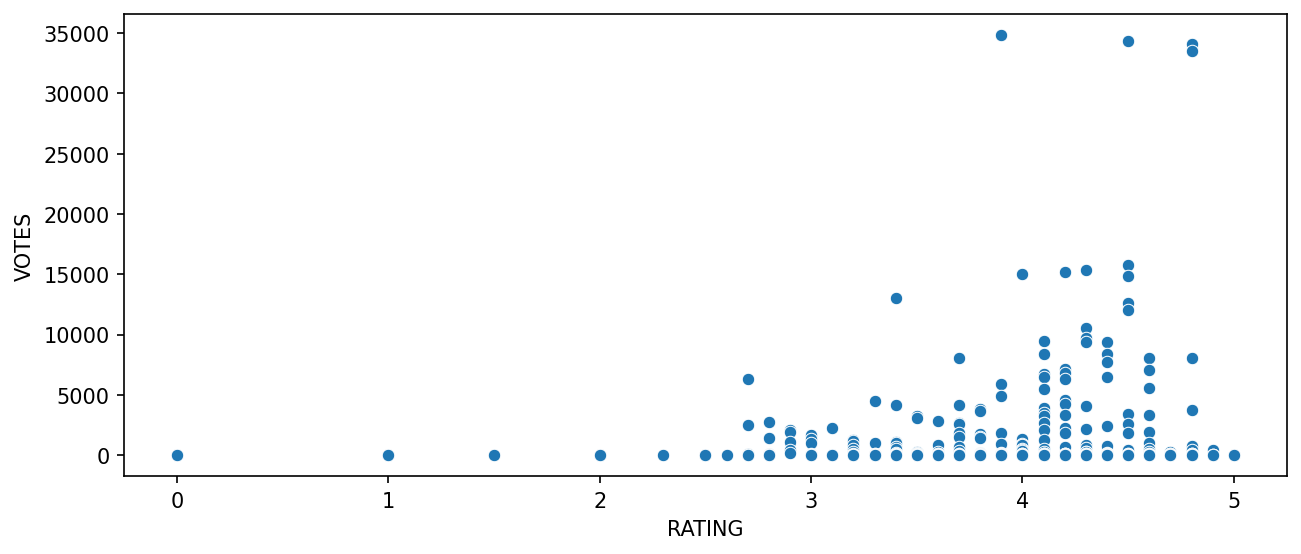

In [6]:
plt.figure(figsize=(10,4), dpi=150)
sns.scatterplot(fandango, x='RATING',y='VOTES');

**Сразу заметим, что мало фильмов с низкими оценками, и несколько фильмов с очень большим количеством отзывов.**

**Найдем количество фильмов, которые имеют нулевое количество голосов (votes).**

In [7]:
len(fandango[fandango['VOTES'] == 0])

69

**Всего в данных 504 записи, можем продолжить исследовать только фильмы с ненулевым количеством голосов (votes).**

In [8]:
fan_df = fandango[fandango['VOTES'] > 0]
fan_df.head()

,FILM,STARS,RATING,VOTES
0,Fifty Shades of Grey (2015),4.0,3.9,34846
1,Jurassic World (2015),4.5,4.5,34390
2,American Sniper (2015),5.0,4.8,34085
3,Furious 7 (2015),5.0,4.8,33538
4,Inside Out (2015),4.5,4.5,15749


**Отобразим распределение отображаемых рейтингов (STARS) и истинных рейтингов на основе голосов пользователей (RATING).**

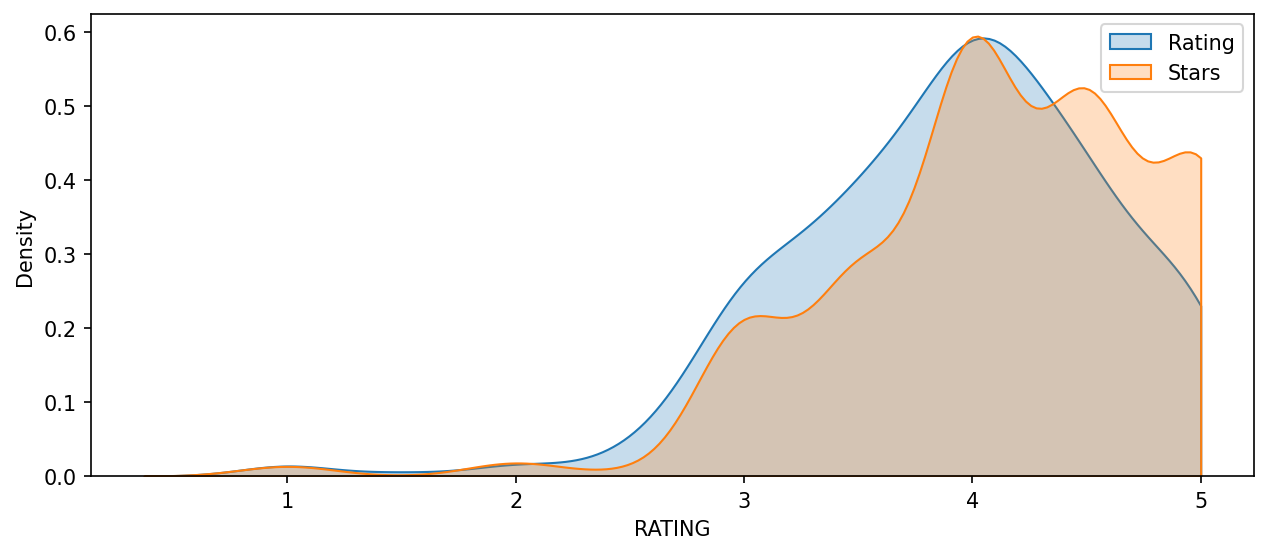

In [9]:
plt.figure(figsize=(10,4), dpi=150)
sns.kdeplot(fan_df, x ='RATING', clip=[0,5], fill=True, label='Rating')
sns.kdeplot(fan_df, x ='STARS', clip=[0,5], fill=True, label='Stars')
plt.legend();

**Посчитаем эту разницу в численном виде.**

In [10]:
fan_df['STARS-DIFF'] = round(fan_df['STARS'] - fan_df['RATING'], 1)
fan_df.head()

C:\Users\1\AppData\Local\Temp\ipykernel_17108\1387264307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fan_df['STARS-DIFF'] = round(fan_df['STARS'] - fan_df['RATING'], 1)


,FILM,STARS,RATING,VOTES,STARS-DIFF
0,Fifty Shades of Grey (2015),4.0,3.9,34846,0.1
1,Jurassic World (2015),4.5,4.5,34390,0.0
2,American Sniper (2015),5.0,4.8,34085,0.2
3,Furious 7 (2015),5.0,4.8,33538,0.2
4,Inside Out (2015),4.5,4.5,15749,0.0


**Отобразим распределения разности STARS-DIFF**

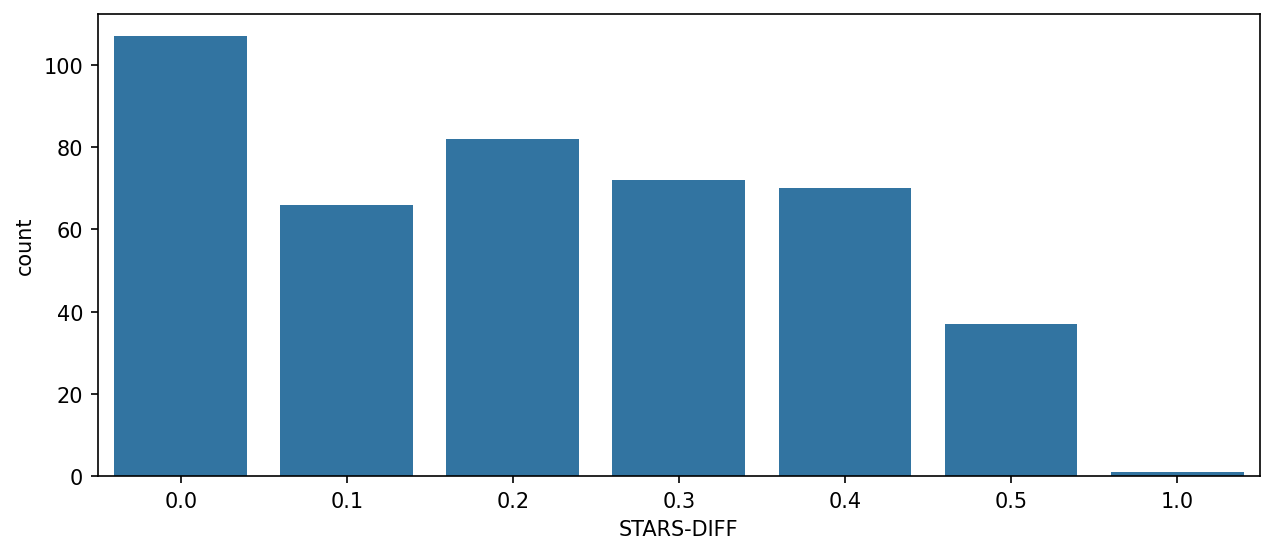

In [11]:
plt.figure(figsize=(10,4), dpi=150)
sns.countplot(fan_df, x='STARS-DIFF');

**Видим, что количество строк с нулевой разностью меньше, чем сумма строк, в которых значения STARS и RATING отличаются, к тому же все разносьти неотрицательны.**

## Часть 2: Сравнение рейтингов Fandango с рейтингами других компаний

In [12]:
all_sites = pd.read_csv("all_sites_scores.csv")
all_sites.head()

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,1330,271107
1,Cinderella (2015),85,80,67,7.5,7.1,249,65709
2,Ant-Man (2015),80,90,64,8.1,7.8,627,103660
3,Do You Believe? (2015),18,84,22,4.7,5.4,31,3136
4,Hot Tub Time Machine 2 (2015),14,28,29,3.4,5.1,88,19560


In [13]:
all_sites.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   FILM                        146 non-null    object 
 1   RottenTomatoes              146 non-null    int64  
 2   RottenTomatoes_User         146 non-null    int64  
 3   Metacritic                  146 non-null    int64  
 4   Metacritic_User             146 non-null    float64
 5   IMDB                        146 non-null    float64
 6   Metacritic_user_vote_count  146 non-null    int64  
 7   IMDB_user_vote_count        146 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 9.2+ KB


In [14]:
all_sites.describe()

,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
count,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000,146.000000
mean,60.849315,63.876712,58.808219,6.519178,6.736986,185.705479,42846.205479
std,30.168799,20.024430,19.517389,1.510712,0.958736,316.606515,67406.509171
min,5.000000,20.000000,13.000000,2.400000,4.000000,4.000000,243.000000
25%,31.250000,50.000000,43.500000,5.700000,6.300000,33.250000,5627.000000
50%,63.500000,66.500000,59.000000,6.850000,6.900000,72.500000,19103.000000
75%,89.000000,81.000000,75.000000,7.500000,7.400000,168.500000,45185.750000
max,100.000000,94.000000,94.000000,9.600000,8.600000,2375.000000,334164.000000


**Заметим, что оценка на разных сайтах выставляется по разным шкалам.**

### Рейтинги от Rotten Tomatoes

**Нарисуем график scatterplot, изображающий для Rotten Tomatoes связь между рейтингами от критиков и пользовательскими рейтингами.**

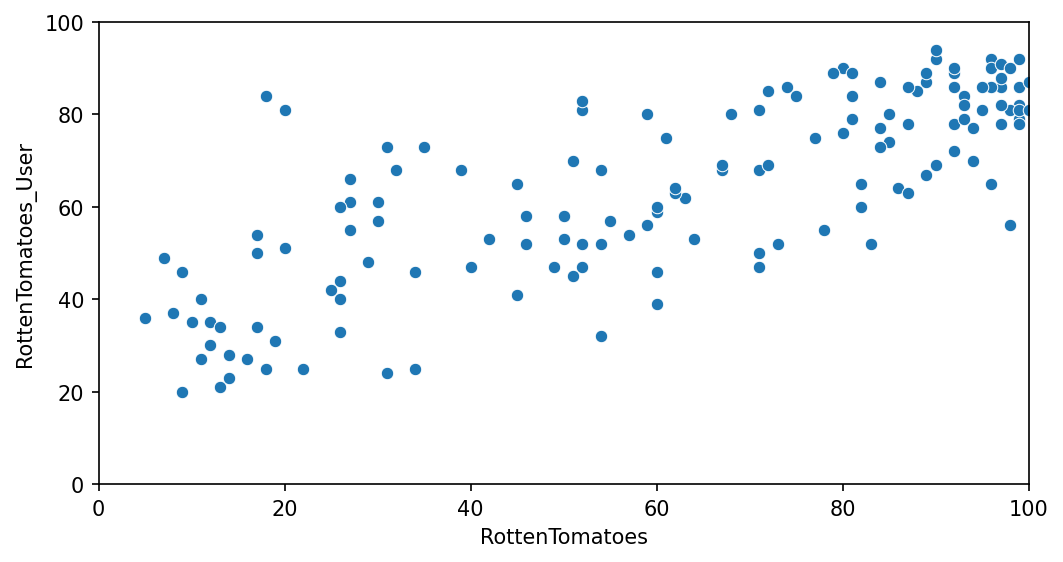

In [15]:
plt.figure(figsize=(8,4), dpi=150)
sns.scatterplot(all_sites, x='RottenTomatoes', y='RottenTomatoes_User')
plt.ylim(0,100)
plt.xlim(0,100);

**Вычислим разницу между рейтингом от критиков и пользовательским рейтингом для Rotten Tomatoes.**

In [16]:
all_sites['Rotten_Diff'] = all_sites['RottenTomatoes'] - all_sites['RottenTomatoes_User']
all_sites.head()

,FILM,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff
0,Avengers: Age of Ultron (2015),74,86,66,7.1,7.8,1330,271107,-12
1,Cinderella (2015),85,80,67,7.5,7.1,249,65709,5
2,Ant-Man (2015),80,90,64,8.1,7.8,627,103660,-10
3,Do You Believe? (2015),18,84,22,4.7,5.4,31,3136,-66
4,Hot Tub Time Machine 2 (2015),14,28,29,3.4,5.1,88,19560,-14


**Вычислим среднюю абсолютную разницу между рейтингами от критиков и пользовательскими рейтингами для Rotten Tomatoes.**

In [17]:
mae = all_sites['Rotten_Diff'].agg('abs')
MAE = mae.mean()
MAE

np.float64(15.095890410958905)

**Отобразим распределение разницы между рейтингами от критиков и пользовательскими рейтингами для Rotten Tomatoes.**

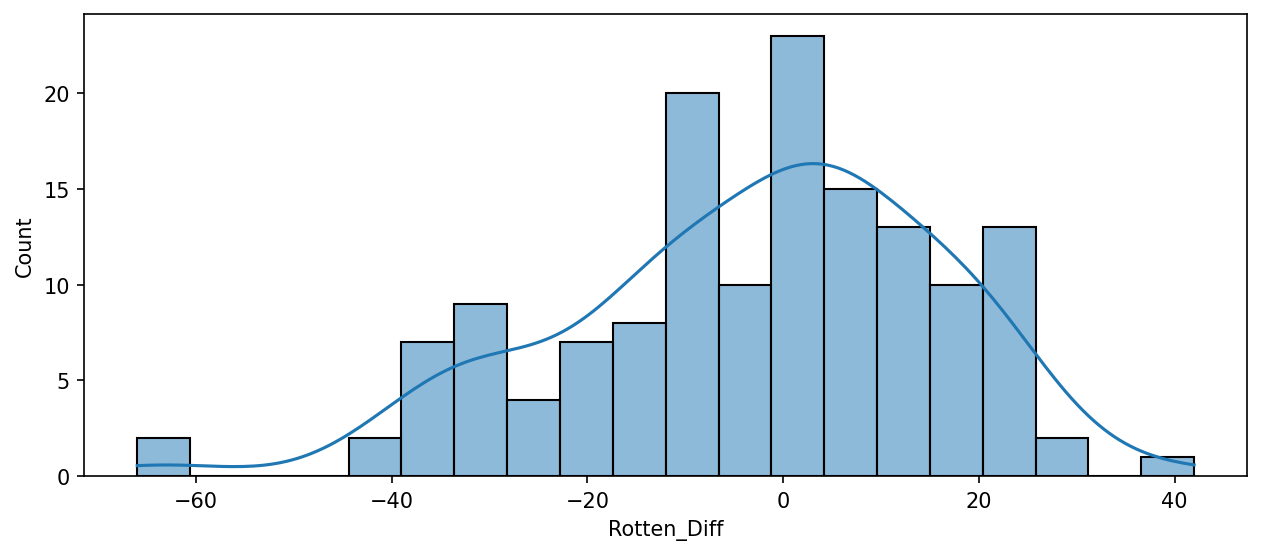

In [18]:
plt.figure(figsize=(10,4), dpi=150)
sns.histplot(all_sites, x='Rotten_Diff', bins = 20, kde=True);

**Отобразим распределение *абсолютных значений* разницы между рейтингами от критиков и пользовательскими рейтингами для Rotten Tomatoes.**

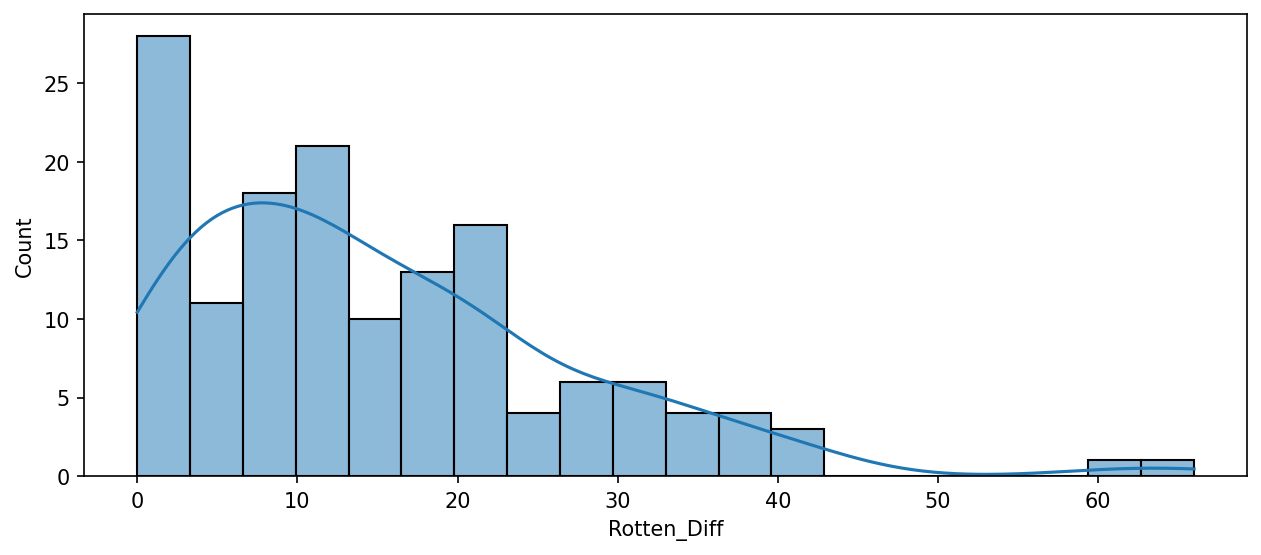

In [19]:
plt.figure(figsize=(10,4), dpi=150)
sns.histplot(all_sites, x=mae, bins = 20, kde=True);


## Рейтинги от MetaCritic


**Нарисуем график scatterplot для сравнения рейтингов Metacritic и Metacritic User.**

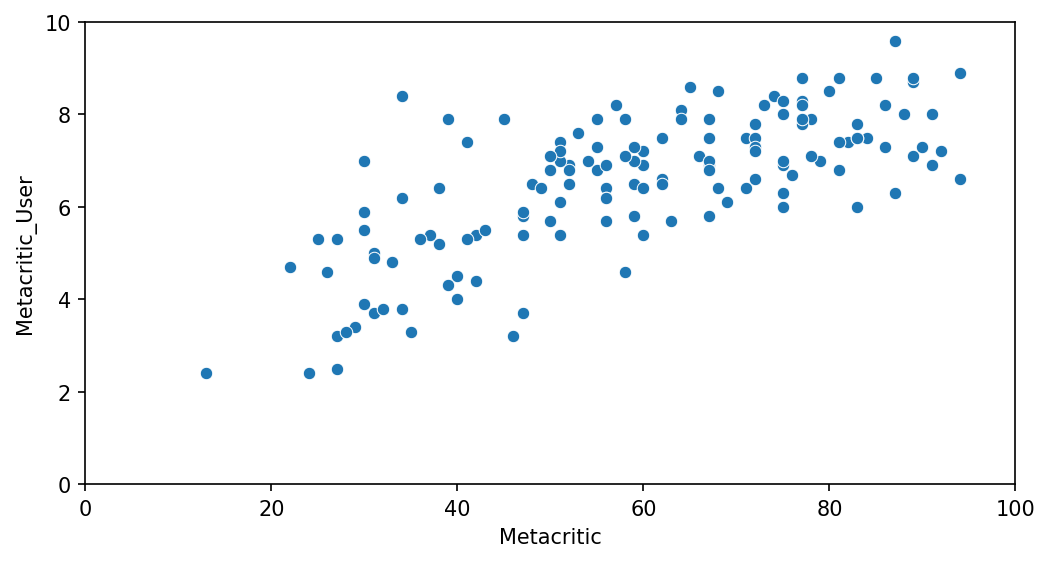

In [20]:
plt.figure(figsize=(8,4), dpi=150)
sns.scatterplot(all_sites, x='Metacritic', y='Metacritic_User')
plt.ylim(0,10)
plt.xlim(0,100);

## Рейтинги от IMDB

**Нарисуем график scatterplot для изображения связи между количеством голосов на MetaCritic и количеством голосов на IMDB.**

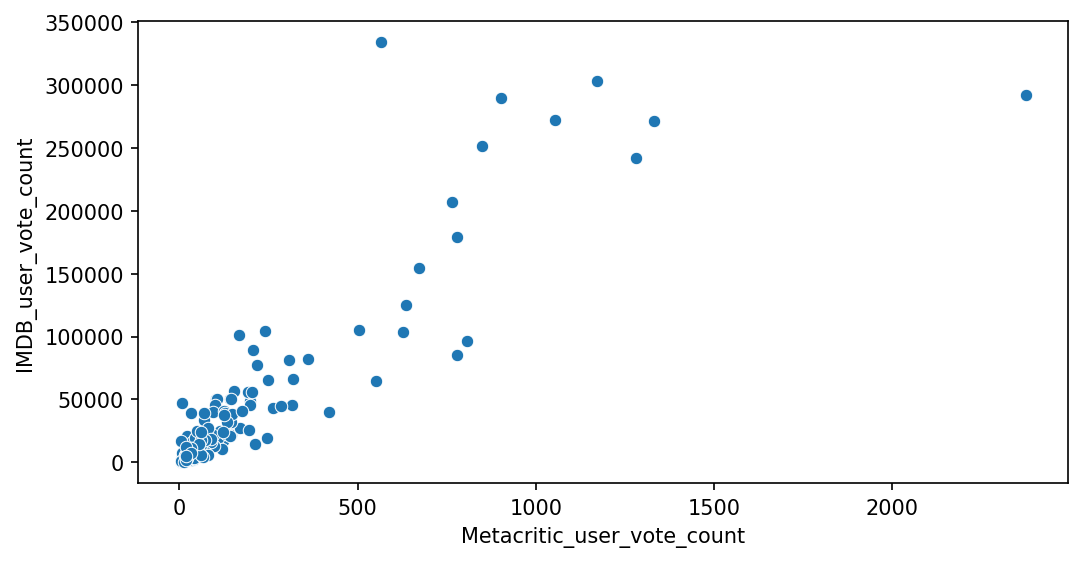

In [21]:
plt.figure(figsize=(8,4), dpi=150)
sns.scatterplot(all_sites, x='Metacritic_user_vote_count', y='IMDB_user_vote_count');

**Видим 2 выброса, которые отклоняются от просматриваемой тенденции**

## Сравнение рейтингов Fandango с рейтингами других компаний

**Обьединим таблицу fandango с таблицей all_sites. Сделаем объединение "*inner* merge", так как хотим иследовать фильмы, которые присутствуют в обоих наборах данных.**

In [22]:
df = pd.merge(fandango, all_sites, on='FILM', how='inner')
df.head()

,FILM,STARS,RATING,VOTES,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff
0,Fifty Shades of Grey (2015),4.0,3.9,34846,25,42,46,3.2,4.2,778,179506,-17
1,Jurassic World (2015),4.5,4.5,34390,71,81,59,7.0,7.3,1281,241807,-10
2,American Sniper (2015),5.0,4.8,34085,72,85,72,6.6,7.4,850,251856,-13
3,Furious 7 (2015),5.0,4.8,33538,81,84,67,6.8,7.4,764,207211,-3
4,Inside Out (2015),4.5,4.5,15749,98,90,94,8.9,8.6,807,96252,8


### Нормализация колонок до диапазона 0-5 в соответствии с колонками STARS и RATINGS от Fandango


In [23]:
df.describe().transpose()['max']

STARS                              5.0
RATING                             4.8
VOTES                          34846.0
RottenTomatoes                   100.0
RottenTomatoes_User               94.0
Metacritic                        94.0
Metacritic_User                    9.6
IMDB                               8.6
Metacritic_user_vote_count      2375.0
IMDB_user_vote_count          334164.0
Rotten_Diff                       42.0
Name: max, dtype: float64

In [24]:
df['RT_Norm'] = np.round(df['RottenTomatoes'] / 20, 1)
df['RTU_Norm'] = np.round(df['RottenTomatoes_User'] / 20, 1)


In [25]:
df['Meta_Norm'] = np.round(df['Metacritic'] / 20, 1)
df['MetaU_Norm'] = np.round(df['Metacritic_User'] / 2, 1)

In [26]:
df['IMDB_Norm'] = np.round(df['IMDB'] / 2, 1)

In [27]:
df.head()

,FILM,STARS,RATING,VOTES,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count,Rotten_Diff,RT_Norm,RTU_Norm,Meta_Norm,MetaU_Norm,IMDB_Norm
0,Fifty Shades of Grey (2015),4.0,3.9,34846,25,42,46,3.2,4.2,778,179506,-17,1.2,2.1,2.3,1.6,2.1
1,Jurassic World (2015),4.5,4.5,34390,71,81,59,7.0,7.3,1281,241807,-10,3.6,4.0,3.0,3.5,3.6
2,American Sniper (2015),5.0,4.8,34085,72,85,72,6.6,7.4,850,251856,-13,3.6,4.2,3.6,3.3,3.7
3,Furious 7 (2015),5.0,4.8,33538,81,84,67,6.8,7.4,764,207211,-3,4.0,4.2,3.4,3.4,3.7
4,Inside Out (2015),4.5,4.5,15749,98,90,94,8.9,8.6,807,96252,8,4.9,4.5,4.7,4.4,4.3


**Для удобства создадим новый DataFrame с названием norm_scores, в котором оставим только нормализованные рейтинги. Также оставим колонки STARS и RATING из исходной таблицы fandango.**

In [28]:
df.columns


Index(['FILM', 'STARS', 'RATING', 'VOTES', 'RottenTomatoes',
       'RottenTomatoes_User', 'Metacritic', 'Metacritic_User', 'IMDB',
       'Metacritic_user_vote_count', 'IMDB_user_vote_count', 'Rotten_Diff',
       'RT_Norm', 'RTU_Norm', 'Meta_Norm', 'MetaU_Norm', 'IMDB_Norm'],
      dtype='object')

In [29]:
norm_df = df[['STARS', 'RATING','RT_Norm', 'RTU_Norm', 'Meta_Norm', 'MetaU_Norm', 'IMDB_Norm']]
norm_df.head()

,STARS,RATING,RT_Norm,RTU_Norm,Meta_Norm,MetaU_Norm,IMDB_Norm
0,4.0,3.9,1.2,2.1,2.3,1.6,2.1
1,4.5,4.5,3.6,4.0,3.0,3.5,3.6
2,5.0,4.8,3.6,4.2,3.6,3.3,3.7
3,5.0,4.8,4.0,4.2,3.4,3.4,3.7
4,4.5,4.5,4.9,4.5,4.7,4.4,4.3


### Сравнение распределений рейтингов от разных компаний

**Отобразим распределение нормализованных рейтингов от всех компаний.**

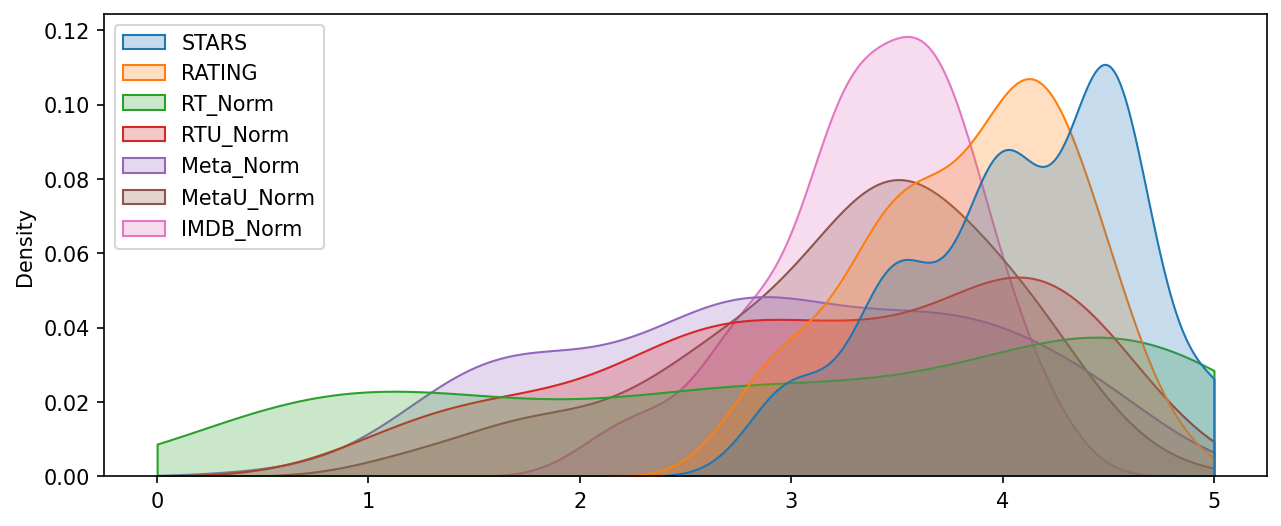

In [30]:
plt.figure(figsize=(10,4), dpi=150)
sns.kdeplot(norm_df, fill=True, clip=[0,5]);

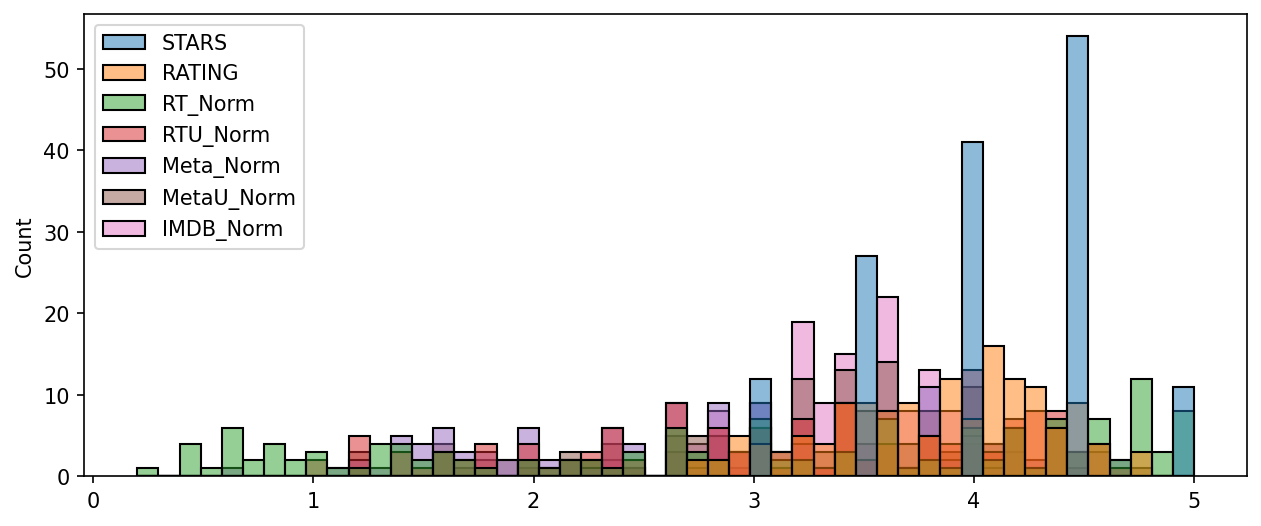

In [31]:
plt.figure(figsize=(10,4), dpi=150)
sns.histplot(norm_df, bins=50);

**Сразу видно, что рейтинги Fandango очень сдвинуты вправо. Интересно также, что рейтинги RT от критиков имеют очень пологое распределение.** 

**Посмотрим на нормализованные рейтинги фильмов на всех сайтах?**

In [32]:
norm_film = df[['FILM','STARS', 'RATING', 'RT_Norm', 'RTU_Norm', 'Meta_Norm', 'MetaU_Norm','IMDB_Norm']]
norm_film.head()

,FILM,STARS,RATING,RT_Norm,RTU_Norm,Meta_Norm,MetaU_Norm,IMDB_Norm
0,Fifty Shades of Grey (2015),4.0,3.9,1.2,2.1,2.3,1.6,2.1
1,Jurassic World (2015),4.5,4.5,3.6,4.0,3.0,3.5,3.6
2,American Sniper (2015),5.0,4.8,3.6,4.2,3.6,3.3,3.7
3,Furious 7 (2015),5.0,4.8,4.0,4.2,3.4,3.4,3.7
4,Inside Out (2015),4.5,4.5,4.9,4.5,4.7,4.4,4.3


**Выделим 10 фильмов с наихудшими рейтингами по версии Rotten Tomatoes Critic.**

In [33]:
worst_film = norm_film.nsmallest(10, 'RT_Norm')
worst_film.head()

,FILM,STARS,RATING,RT_Norm,RTU_Norm,Meta_Norm,MetaU_Norm,IMDB_Norm
49,Paul Blart: Mall Cop 2 (2015),3.5,3.5,0.2,1.8,0.6,1.2,2.2
25,Taken 3 (2015),4.5,4.1,0.4,2.3,1.3,2.3,3.0
28,Fantastic Four (2015),3.0,2.7,0.4,1.0,1.4,1.2,2.0
54,Hot Pursuit (2015),4.0,3.7,0.4,1.8,1.6,1.8,2.4
84,Hitman: Agent 47 (2015),4.0,3.9,0.4,2.4,1.4,1.6,3.0


**Отобразим распределение рейтингов от всех компаний для 10 фильмов с наихудшими рейтингами.**

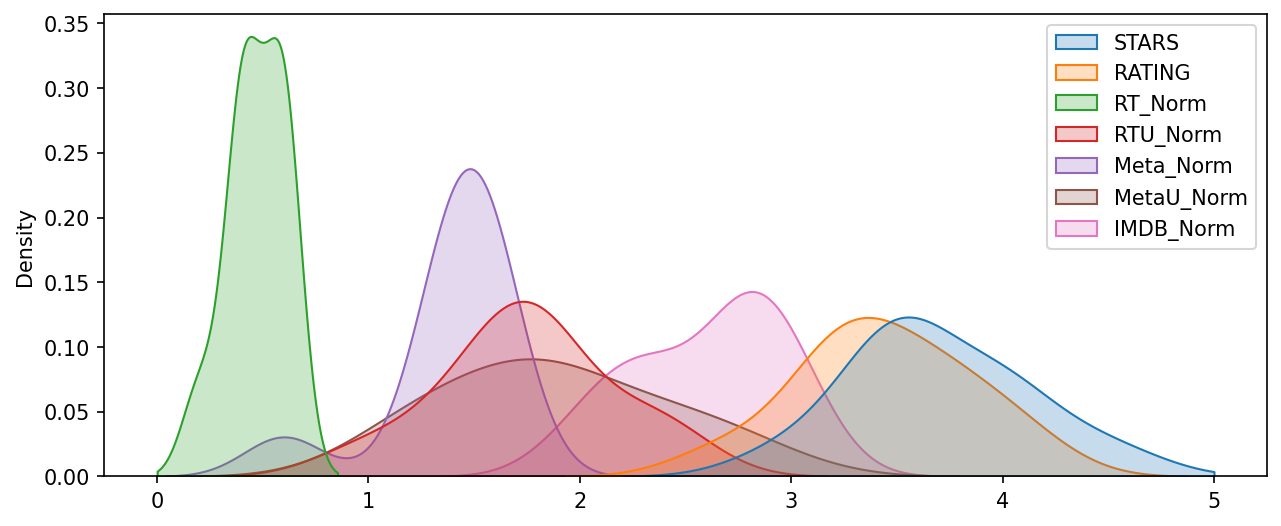

In [34]:
plt.figure(figsize=(10,4), dpi=150)
sns.kdeplot(worst_film, fill=True, clip=[0,5]);

**Аналогично видно, что рейтинги Fandango очень сдвинуты вправо.**

**Численно выведем необходимые данные для анализа рейтингов сайта fandango.**

In [35]:
df_selected = norm_df = df[['STARS', 'RATING','RT_Norm', 'RTU_Norm', 'Meta_Norm', 'MetaU_Norm', 'IMDB_Norm']]
df_metrics = df_selected.agg(['mean', 'median', 'min', 'max', 'var']).round(2)
df_metrics.index = ['mean', 'median', 'min', 'max', 'var']
df_metrics.transpose()

,mean,median,min,max,var
STARS,4.09,4.0,3.0,5.0,0.29
RATING,3.84,3.9,2.7,4.8,0.25
RT_Norm,3.03,3.2,0.2,5.0,2.28
RTU_Norm,3.18,3.3,1.0,4.7,0.99
Meta_Norm,2.94,3.0,0.6,4.7,0.96
MetaU_Norm,3.25,3.4,1.2,4.8,0.58
IMDB_Norm,3.37,3.4,2.0,4.3,0.23


**Видим, что для STARS и RATING все характеристики кроме дисперсии выше, по сравнению с остальными. По результатам вычисления дисперсии можно сделать вывод, что значения в данных очень близки друг к другу и к среднему значению. Всё это действительно подтверждает, что данные на fandango искуственные.**

----
**Итак, мы проверили результаты стать о рейтингах фильмов на сайте fandango. Они действительно завышены по сравнению с другими сайтами, это видно как графике распределения оценок для всех фильмов, так и на графике распределния оценок для 10 худших фильмов по мнению экспертов (RottenTomatoes).**